# **Import Libraries**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

In [3]:
# define project root path
PROJECT_ROOT = Path().resolve().parent

# **Load Data**

In [4]:
# load all data
merchant_profile = pd.read_csv(f'{PROJECT_ROOT}/data/raw/merchant_profiles.csv')
merchants = pd.read_csv(f'{PROJECT_ROOT}/data/raw/merchants.csv')
trx_raw = pd.read_csv(f'{PROJECT_ROOT}/data/raw/transactions_raw.csv')

In [5]:
# quick look at each df
print('Merchant Dataframe:')
print(merchants.info())
display(merchants.head())

Merchant Dataframe:
<class 'pandas.DataFrame'>
RangeIndex: 408 entries, 0 to 407
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   merchant_id        408 non-null    str    
 1   nama               396 non-null    str    
 2   kategori           408 non-null    str    
 3   sub_kategori       408 non-null    str    
 4   tipe               408 non-null    str    
 5   kota               408 non-null    str    
 6   kecamatan          387 non-null    str    
 7   is_nasabah_bni     408 non-null    str    
 8   produk_bni         260 non-null    str    
 9   tgl_registrasi     260 non-null    str    
 10  status             260 non-null    str    
 11  avg_omzet_bulanan  392 non-null    float64
dtypes: float64(1), str(11)
memory usage: 38.4 KB
None


,merchant_id,nama,kategori,sub_kategori,tipe,kota,kecamatan,is_nasabah_bni,produk_bni,tgl_registrasi,status,avg_omzet_bulanan
0,M0001,Kafe Berkah,F&B,cafe,retailer,Jakarta,Kemang,Tidak,NaN,NaN,NaN,102671254.0
1,M0002,Toko Grosir Jaya,F&B,restaurant,supplier,Jakarta,Pluit,Ya,EDC,2024-08-31,aktif,263453794.0
2,M0003,Kafe Pak Haji,F&B,warung,retailer,Depok,Cimanggis,Ya,QRIS,2020-10-15,aktif,117614123.0
3,M0004,Resto Abadi,F&B,catering,retailer,Bogor,Dramaga,Ya,"EDC, QRIS",2025-10-08,aktif,258582893.0
4,M0005,Warung Abadi,F&B,warung,retailer,Bekasi,Summarecon,Ya,"EDC, QRIS, Giro",2025-12-08,aktif,53183670.0


In [6]:
print("Raw Transactions Dataframe:")
print(trx_raw.info())
display(trx_raw.head())

Raw Transactions Dataframe:
<class 'pandas.DataFrame'>
RangeIndex: 45900 entries, 0 to 45899
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   trx_id       45900 non-null  str    
 1   timestamp    45900 non-null  str    
 2   source_id    45900 non-null  str    
 3   target_id    45900 non-null  str    
 4   amount       44642 non-null  float64
 5   channel      45441 non-null  str    
 6   status       45900 non-null  str    
 7   description  18034 non-null  str    
 8   ref_number   45900 non-null  str    
dtypes: float64(1), str(8)
memory usage: 3.2 MB
None


,trx_id,timestamp,source_id,target_id,amount,channel,status,description,ref_number
0,T024476,2026-04-26 02:34:27,M0361,M0342,1076158.0,QRIS,success,Payment invoice,REF83725999
1,T006710,2025-10-27 10:58:02,M0174,M0177,3789392.0,transfer,success,NaN,REF63546127
2,T029055,2025-09-01 20:37:11,C00512,M0217,78057.0,EDC,success,NaN,REF73191524
3,T001858,2026-04-15 23:06:58,M0320,M0045,1525153.0,transfer,success,Pembayaran bahan,REF06445482
4,T043949,2025-10-22 10:30:13,C00386,M0386,98291.0,EDC,success,NaN,REF53019811


In [7]:
print("Merchant Profiles Dataframe:")
print(merchant_profile.info())
print("\n", merchant_profile.head(3))

Merchant Profiles Dataframe:
<class 'pandas.DataFrame'>
RangeIndex: 408 entries, 0 to 407
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   merchant_id            408 non-null    str    
 1   lama_beroperasi_tahun  378 non-null    float64
 2   jumlah_karyawan        364 non-null    float64
 3   rating_google          304 non-null    float64
 4   jumlah_outlet          381 non-null    float64
 5   has_website            312 non-null    str    
 6   has_social_media       334 non-null    str    
dtypes: float64(4), str(3)
memory usage: 22.4 KB
None

   merchant_id  lama_beroperasi_tahun  jumlah_karyawan  rating_google  \
0       M0001                    NaN             37.0            3.0   
1       M0002                    1.0             26.0            4.7   
2       M0003                    4.0             26.0            4.6   

   jumlah_outlet has_website has_social_media  
0            1.0 

# **Data Quality Assessment**

## **2.1 Missing Values Summary**

In [8]:
def missing_summary(df, table_name):
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(2)
    summary = pd.DataFrame({
        'missing_count': missing,
        'missing_pct': pct
    })
    summary = summary[summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)

    print(f'Checking Missing Values on Table => {table_name}')
    if len(summary) == 0:
        print('There is no missing values.')
        print()
    else:
        print(summary)
        print()

    return summary

In [9]:
# check missing summary on each dataframe
missing_merchants = missing_summary(merchants, "merchants")
missing_trx = missing_summary(trx_raw, "transactions_raw")
missing_profile = missing_summary(merchant_profile, "merchant_profiles")

Checking Missing Values on Table => merchants
                   missing_count  missing_pct
tgl_registrasi               148        36.27
produk_bni                   148        36.27
status                       148        36.27
kecamatan                     21         5.15
avg_omzet_bulanan             16         3.92
nama                          12         2.94

Checking Missing Values on Table => transactions_raw
             missing_count  missing_pct
description          27866        60.71
amount                1258         2.74
channel                459         1.00

Checking Missing Values on Table => merchant_profiles
                       missing_count  missing_pct
rating_google                    104        25.49
has_website                       96        23.53
has_social_media                  74        18.14
jumlah_karyawan                   44        10.78
lama_beroperasi_tahun             30         7.35
jumlah_outlet                     27         6.62



## **2.2 Duplicate Detection**

In [10]:
# normalized merchants name
merchants['nama_normalized'] = (
    merchants['nama']
    .fillna('')
    .str.lower()
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True) # delete double spaces
)

# find the names appear more than once after normalizing process
nama_duplicates = merchants[
    merchants['nama_normalized'].duplicated(keep=False) &
    (merchants['nama_normalized'] != '')
].sort_values('nama_normalized')

print(f"Total rows with similar names: {len(nama_duplicates)}")
if len(nama_duplicates) > 0:
    print(nama_duplicates[['merchant_id', 'nama', 'nama_normalized', 'kategori', 'kota', 'is_nasabah_bni']].to_string())

Total rows with similar names: 134
    merchant_id                      nama           nama_normalized     kategori       kota is_nasabah_bni
347       M0348               Auto Berkah               auto berkah   Automotive    Bandung          Tidak
366       M0367               Auto Berkah               auto berkah   Automotive      Bogor             Ya
116       M0117          Bakery Nusantara          bakery nusantara          F&B     Bekasi          Tidak
39        M0040          Bakery Nusantara          bakery nusantara          F&B  Tangerang             Ya
373       M0374             Bengkel Buana             bengkel buana   Automotive      Bogor          Tidak
365       M0366             Bengkel Buana             bengkel buana   Automotive      Depok             Ya
395       M0396             Bengkel Karya             bengkel karya   Automotive      Bogor             Ya
376       M0377             Bengkel Karya             bengkel karya   Automotive    Jakarta             Ya
40

In [11]:
# check duplicates ref_number on transactions table
ref_dupes = trx_raw[trx_raw.duplicated(subset='ref_number', keep=False)].sort_values('ref_number')
print(f"Total rows of dupliacted ref_number: {len(ref_dupes)}")
print(f"Total unique ref_number got duplicated: {ref_dupes['ref_number'].nunique()}")
print(f"\nContoh duplikat (5 pertama):")
print(ref_dupes.head(5)[['trx_id', 'ref_number', 'source_id', 'target_id', 'amount', 'status']])

Total rows of dupliacted ref_number: 1826
Total unique ref_number got duplicated: 913

Contoh duplikat (5 pertama):
        trx_id   ref_number source_id target_id     amount   status
24507  T045855  REF00388599    C00558     M0361   382815.0  success
23070  T044772  REF00388599    C00558     M0361   382815.0  success
42901  T024503  REF00618692     M0193     M0151  2637598.0  success
29259  T045595  REF00618692     M0193     M0151  2637598.0  success
4501   T045403  REF00640814     M0407     M0116  9106476.0  success


# **2.3 Detect Anomalies**

In [12]:
# check amount anomalies on transaction data
print('Amount analysis (before cleaning):')
print(f"\nNULL amount:     {trx_raw['amount'].isna().sum()}")
print(f"Negative amount: {(trx_raw['amount'] < 0).sum()}")
print(f"Zero amount:     {(trx_raw['amount'] == 0).sum()}")

display(trx_raw['amount'].describe())

Amount analysis (before cleaning):

NULL amount:     1258
Negative amount: 459
Zero amount:     20


count    4.464200e+04
mean     3.786142e+06
std      2.720444e+07
min     -2.196576e+07
25%      1.269692e+05
50%      7.900385e+05
75%      3.824428e+06
max      2.105106e+09
Name: amount, dtype: float64

In [13]:
# check negative amount distribution => should be refund
refunds = trx_raw[trx_raw['amount'] < 0]
print('Refund Transactions:')
print(f'\nRefunds total: {len(refunds)}')
print(f"Check refunds unique description: {list(refunds['description'].unique())}")

Refund Transactions:

Refunds total: 459
Check refunds unique description: ['Pengembalian', 'Refund', 'Retur barang', 'Refund - barang rusak']


In [14]:
# check transaction amount = 0 => should be test transactions
test_trx = trx_raw[trx_raw['amount'] == 0]
print(f"Test transactions (amount=0):")
print(f"\nJumlah: {len(test_trx)}")
print(f"Check test transaction unique description: {list(test_trx['description'].unique())}")

Test transactions (amount=0):

Jumlah: 20
Check test transaction unique description: ['Test transaction']


In [15]:
# outlier detection on amount

# filter only on positive amount and success transaction
valid_amounts = trx_raw[(trx_raw['amount'] > 0) & (trx_raw['status'] == 'success')]['amount']

# define outliers boundaries
Q1 = valid_amounts.quantile(0.25)
Q3 = valid_amounts.quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 3 * IQR  # 3 times IQR for less-aggresive outlier detection

# generate the information of outlier findings
outliers = valid_amounts[valid_amounts > upper_bound]
print(f"Outlier Detection (IQR method, 3x):")
print(f"\nQ1: {Q1:,.0f} | Q3: {Q3:,.0f} | IQR: {IQR:,.0f}")
print(f"Upper bound: {upper_bound:,.0f}")
print(f"Total outliers: {len(outliers)} ({len(outliers)/len(valid_amounts)*100:.2f}%) of {len(valid_amounts)} data")
print(f"Range outliers: {outliers.min():,.0f} — {outliers.max():,.0f}")

Outlier Detection (IQR method, 3x):

Q1: 135,185 | Q3: 3,873,559 | IQR: 3,738,374
Upper bound: 15,088,681
Total outliers: 1614 (3.83%) of 42093 data
Range outliers: 15,098,836 — 2,105,106,100


In [16]:
# check status distribution
print('Transaction Status Distribution:\n')
print(trx_raw['status'].value_counts(normalize=True).round(4) * 100)

Transaction Status Distribution:

status
success    92.69
failed      4.64
pending     2.67
Name: proportion, dtype: float64


In [17]:
# check channel distribution
print('Transaction Channel Distribution:\n')
print(trx_raw['channel'].value_counts(normalize=True).round(4) * 100)

Transaction Channel Distribution:

channel
transfer    41.68
QRIS        34.66
EDC         23.66
Name: proportion, dtype: float64


In [18]:
# check transaction type => Merchants to Merchants and Customers to Merchants
trx_raw['trx_type'] = np.where(
    trx_raw['source_id'].str.startswith('M'), 
    'M2M (Merchant-to-Merchant)', 
    'C2M (Customer-to-Merchant)'
)

print('Transaction type:')
print()
print(trx_raw['trx_type'].value_counts(normalize=True).round(4) * 100)

Transaction type:

trx_type
M2M (Merchant-to-Merchant)    60.03
C2M (Customer-to-Merchant)    39.97
Name: proportion, dtype: float64


In [19]:
# check potential anomaly transaction time

# convert timestamp data type into datetime
print('Initial type data of timestamp:', trx_raw['timestamp'].dtype)
print('Changing timestamp type data into datetime. . . .')
trx_raw['timestamp_dt'] = pd.to_datetime(trx_raw['timestamp'])
print('Type data of timestamp after casting:', trx_raw['timestamp_dt'].dtype)
trx_raw['hour'] = trx_raw['timestamp_dt'].dt.hour

# check odd hours of transaction time
odd_hours = trx_raw[trx_raw['hour'].between(1, 4)]
print(f'\nTotal of odd hour transactions (01-00:04:59): {len(odd_hours)} transactions')


Initial type data of timestamp: str
Changing timestamp type data into datetime. . . .
Type data of timestamp after casting: datetime64[us]

Total of odd hour transactions (01-00:04:59): 7820 transactions


# **3. Data Cleaning**

We have already finished on checking the data quality. Now we can take some actions to clean the data based on our prior observation. 

## **3.1 Clean Merchants**

In [20]:
# drop near-duplicate merchants name => keep the most completed data

# completeness => calculate non-null columns
merchants_clean = merchants.copy()
merchants_clean['completeness'] = merchants_clean.drop(columns=['nama_normalized']).notna().sum(axis=1)

# Sort by completeness descending, then drop duplicated nama_normalized
merchants_clean = (
    merchants_clean
    .sort_values('completeness', ascending=False)
    .drop_duplicates(subset='nama_normalized', keep='first')
    .drop(columns=['completeness', 'nama_normalized'])
    .reset_index(drop=True)
)

print(f'Merchants before dropping duplicated: {len(merchants)}')
print(f"Merchants after dropping duplicated: {len(merchants_clean)}")

Merchants before dropping duplicated: 408
Merchants after dropping duplicated: 324


In [21]:
# fill missing values on categorical columns

# fill null on nama column with 'unknown_<merchant_id>'
merchants_clean['nama'] = merchants_clean.apply(lambda row: f"Unknown_{row['merchant_id']}" if pd.isna(row['nama']) else row['nama'],axis=1)

# fill null kecamatan with 'Unknown'
merchants_clean['kecamatan'] = merchants_clean['kecamatan'].fillna('Unknown')

merchants_clean.isna().sum()

merchant_id           0
nama                  0
kategori              0
sub_kategori          0
tipe                  0
kota                  0
kecamatan             0
is_nasabah_bni        0
produk_bni           96
tgl_registrasi       96
status               96
avg_omzet_bulanan    11
dtype: int64

Average omzet bulanan skewness: 4.410230441003654


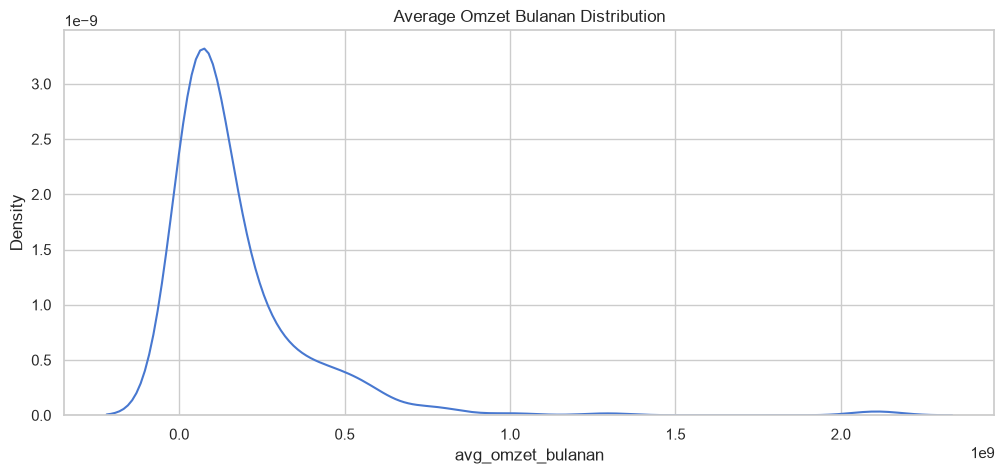

In [22]:
# check skewness avg_omzet_bulanan
print('Average omzet bulanan skewness:', merchants_clean['avg_omzet_bulanan'].skew())
sns.kdeplot(data=merchants_clean, x='avg_omzet_bulanan')
plt.title('Average Omzet Bulanan Distribution')
plt.show()

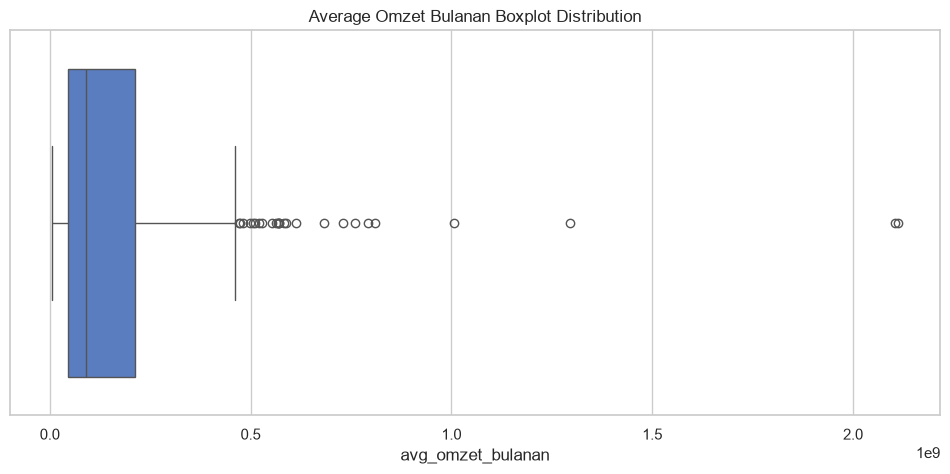

In [23]:
sns.boxplot(data=merchants_clean, x='avg_omzet_bulanan')
plt.title('Average Omzet Bulanan Boxplot Distribution')
plt.show()

Average omzet bulanan seems skewed-right distribution, yet the boxplot distribution also shows many data points outside of Q3 boundary. The most suitable way to impute missing values considering those condition is using median which robust to the outliers data.

In [24]:
# fill NULL avg_omzet_bulanan with median per category-type
merchants_clean['avg_omzet_bulanan'] = merchants_clean.groupby(['kategori', 'tipe'])['avg_omzet_bulanan'].transform(lambda x: x.fillna(x.median()))

# re-check missing values
merchants_clean.isna().sum()

merchant_id           0
nama                  0
kategori              0
sub_kategori          0
tipe                  0
kota                  0
kecamatan             0
is_nasabah_bni        0
produk_bni           96
tgl_registrasi       96
status               96
avg_omzet_bulanan     0
dtype: int64

In [25]:
produk_null = (merchants_clean['produk_bni'].isna())
tanggal_null = (merchants_clean['tgl_registrasi'].isna())
status_null = (merchants_clean['status'].isna())

merchants_null = merchants_clean[produk_null | tanggal_null | status_null]
print(f'Total merchants is_nasabah_bni == Tidak: {len(merchants_null['is_nasabah_bni'])}')
display(merchants_null.head())

Total merchants is_nasabah_bni == Tidak: 96


,merchant_id,nama,kategori,sub_kategori,tipe,kota,kecamatan,is_nasabah_bni,produk_bni,tgl_registrasi,status,avg_omzet_bulanan
228,M0198,Fashion Anugrah,Fashion,textile,retailer,Tangerang,BSD,Tidak,NaN,NaN,NaN,75402621.0
229,M0197,Butik Bersama,Fashion,accessories,retailer,Bandung,Buah Batu,Tidak,NaN,NaN,NaN,29636827.0
230,M0185,Outlet Harmoni,Fashion,footwear,retailer,Tangerang,Cipondoh,Tidak,NaN,NaN,NaN,53697848.0
231,M0186,CV Konveksi Bang Jali,Fashion,footwear,supplier,Depok,Cimanggis,Tidak,NaN,NaN,NaN,520968634.0
232,M0189,Fashion Barokah,Fashion,clothing,retailer,Bekasi,Grand Galaxy,Tidak,NaN,NaN,NaN,30642106.0


It's now all clear that remaining missing values on produk_bni, tgl_registrasi, status are expected because they have no partnership with BNI.

In [26]:
# summarize cleaning results
print(f"Total final merchants: {len(merchants_clean)}")
print(f"Total is_nasabah_bni == Ya: {(merchants_clean['is_nasabah_bni'] == 'Ya').sum()}")
print(f"Total is_nasabah_bni == Tidak: {(merchants_clean['is_nasabah_bni'] == 'Tidak').sum()}")
print(f"Retailer: {(merchants_clean['tipe'] == 'retailer').sum()}")
print(f"Supplier: {(merchants_clean['tipe'] == 'supplier').sum()}")
print(f"NULL nama: {merchants_clean['nama'].isna().sum()}")

Total final merchants: 324
Total is_nasabah_bni == Ya: 228
Total is_nasabah_bni == Tidak: 96
Retailer: 236
Supplier: 88
NULL nama: 0


## **3.2 Clean Transactions**

In [27]:
# remove duplicates of ref_number 
trx_clean = trx_raw.copy()

# remove duplicate ref_number
before_duplicates_removal = len(trx_clean)
trx_clean = trx_clean.drop_duplicates(subset='ref_number', keep='first')
print(f"Remove ref_number duplicates: {before_duplicates_removal} → {len(trx_clean)} (delete {before_duplicates_removal - len(trx_clean)})")

# remove failed & pending transactions
before_status_removal = len(trx_clean)
trx_clean = trx_clean[trx_clean['status'] == 'success']
print(f"Remove failed & pending status transactions: {before_status_removal} → {len(trx_clean)} (delete {before_status_removal - len(trx_clean)})")
 
# remove null amount
before = len(trx_clean)
trx_clean = trx_clean.dropna(subset=['amount'])
print(f"Delete null amount: {before} → {len(trx_clean)} (delete {before - len(trx_clean)})")
 
# remove negative amount (refunds) dan zero amount (test)
before = len(trx_clean)
trx_clean = trx_clean[trx_clean['amount'] > 0]
print(f"Delete refund and test amount (amount<=0): {before} → {len(trx_clean)} (delete {before - len(trx_clean)})")
 
# fill NULL channel with 'unknown'
trx_clean['channel'] = trx_clean['channel'].fillna('unknown')
 
# parse timestamp
trx_clean['timestamp_dt'] = pd.to_datetime(trx_clean['timestamp'])
trx_clean['hour'] = trx_clean['timestamp_dt'].dt.hour
trx_clean['day_of_week'] = trx_clean['timestamp_dt'].dt.day_name()
trx_clean['month'] = trx_clean['timestamp_dt'].dt.to_period('M')
 
# label transaction type
trx_clean['trx_type'] = np.where(trx_clean['source_id'].str.startswith('M'), 'M2M', 'C2M')
 
print(f"\nTransactions final: {len(trx_clean)}")
print(f"Merchant-to-Merchant (M2M): {(trx_clean['trx_type'] == 'M2M').sum()}")
print(f"Customer-to-Merchant (C2M): {(trx_clean['trx_type'] == 'C2M').sum()}")

Remove ref_number duplicates: 45900 → 44987 (delete 913)
Remove failed & pending status transactions: 44987 → 41708 (delete 3279)
Delete null amount: 41708 → 41708 (delete 0)
Delete refund and test amount (amount<=0): 41708 → 41265 (delete 443)

Transactions final: 41265
Merchant-to-Merchant (M2M): 24527
Customer-to-Merchant (C2M): 16738


## **3.3 Clean Merchant Profiles**

In [28]:
# copy merchant profile df
profile_clean = merchant_profile.copy()
profile_clean.head()

,merchant_id,lama_beroperasi_tahun,jumlah_karyawan,rating_google,jumlah_outlet,has_website,has_social_media
0,M0001,NaN,37.0,3.0,1.0,Tidak,Tidak
1,M0002,1.0,26.0,4.7,1.0,NaN,Tidak
2,M0003,4.0,26.0,4.6,2.0,NaN,Tidak
3,M0004,4.0,25.0,NaN,NaN,Tidak,Tidak
4,M0005,15.0,25.0,NaN,1.0,Ya,Ya


In [29]:
# check skewness on profile_clean numeric data
for col in profile_clean.select_dtypes(include='number').columns:
    print(f'Skewness of {col} column: {profile_clean[col].skew()}')

Skewness of lama_beroperasi_tahun column: 0.01961094017490438
Skewness of jumlah_karyawan column: 1.0564909193477294
Skewness of rating_google column: -0.04579965764559992
Skewness of jumlah_outlet column: 2.144765319489291


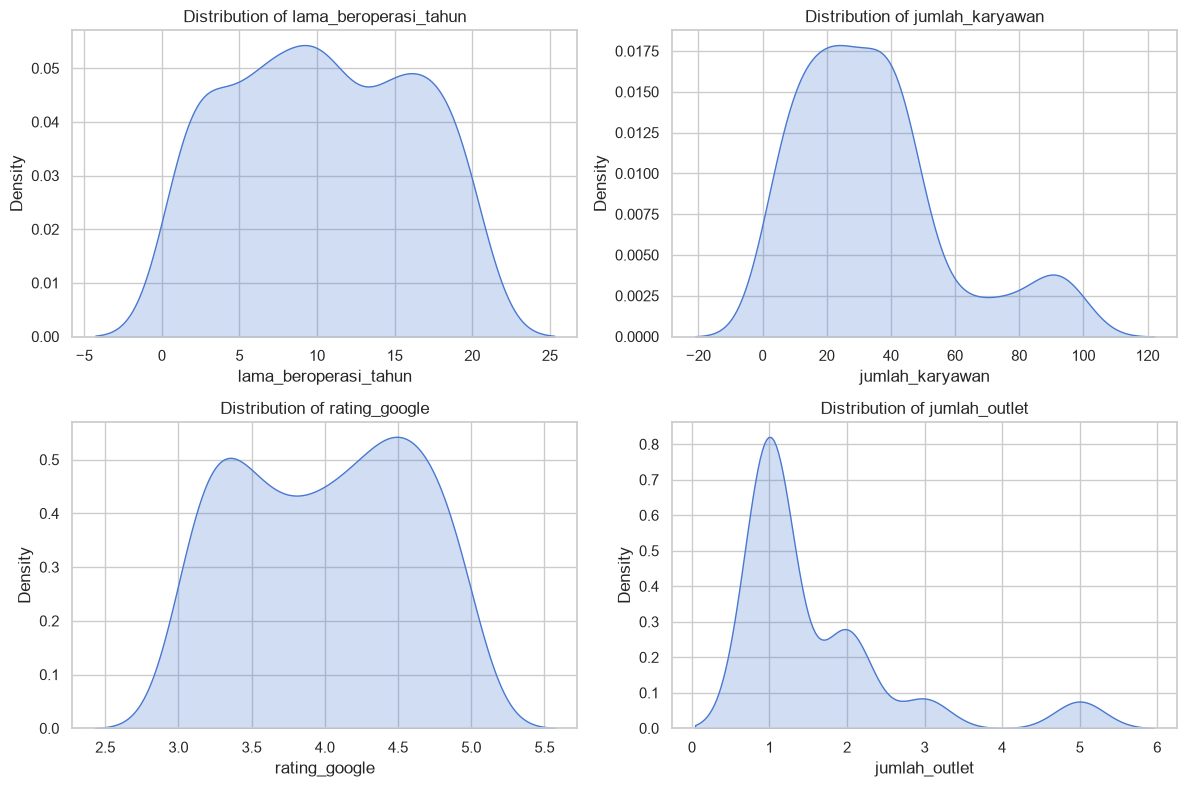

In [30]:
# make density subplots visualization
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

# convert array 2d into 1d for looping purposes
ax = ax.flatten()

for i, col in enumerate(profile_clean.select_dtypes(include='number').columns):  
    sns.kdeplot(
        data=profile_clean,
        x=col,
        fill=True,
        ax=ax[i]
    )
    ax[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

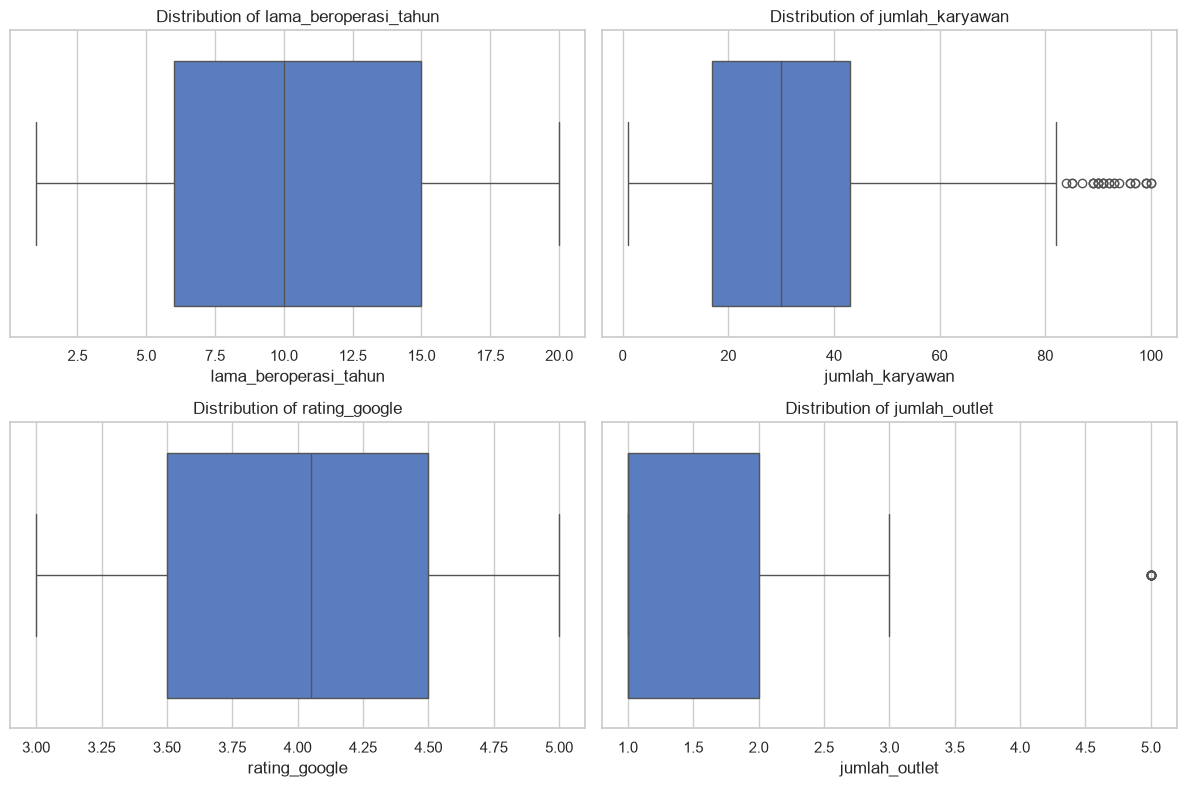

In [31]:
# make boxplot subplots visualization
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

# convert array 2d into 1d for looping purposes
ax = ax.flatten()

for i, col in enumerate(profile_clean.select_dtypes(include='number').columns):  
    sns.boxplot(
        data=profile_clean,
        x=col,
        fill=True,
        ax=ax[i]
    )
    ax[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [32]:
# fill missing value with median
for col in ['lama_beroperasi_tahun', 'jumlah_karyawan', 'jumlah_outlet']:
    median_val = profile_clean[col].median()
    null_count = profile_clean[col].isna().sum()
    profile_clean[col] = profile_clean[col].fillna(median_val)
    print(f"Fill {col} NULL ({null_count}) with median ({median_val})")

# let null value on rating_google, make new features has_rating containing binary values 
profile_clean['has_rating'] = profile_clean['rating_google'].notna().astype(int)
profile_clean['rating_google'] = profile_clean['rating_google'].fillna(0)  # 0 = no rating

# has_website dan has_social_media — encode ke binary
profile_clean['has_website'] = (profile_clean['has_website'] == 'Ya').astype(int)
profile_clean['has_social_media'] = (profile_clean['has_social_media'] == 'Ya').astype(int)

print(f"\nProfile clean shape: {profile_clean.shape}")
print(f"Missing values: {profile_clean.isnull().sum().sum()}")

Fill lama_beroperasi_tahun NULL (30) with median (10.0)
Fill jumlah_karyawan NULL (44) with median (30.0)
Fill jumlah_outlet NULL (27) with median (1.0)

Profile clean shape: (408, 8)
Missing values: 0


# **4. Exploratory Data Analysis**

## **4.1 Merchant Overview**

In [33]:
merchants_clean.groupby(['kategori', 'is_nasabah_bni']).size().unstack(fill_value=0)

is_nasabah_bni,Tidak,Ya
kategori,,
Automotive,14,37
Electronics,11,36
F&B,29,69
Fashion,23,41
Grocery,19,45


In [34]:
pd.crosstab(
    merchants_clean['kategori'],
    merchants_clean['is_nasabah_bni']
)

is_nasabah_bni,Tidak,Ya
kategori,,
Automotive,14,37
Electronics,11,36
F&B,29,69
Fashion,23,41
Grocery,19,45


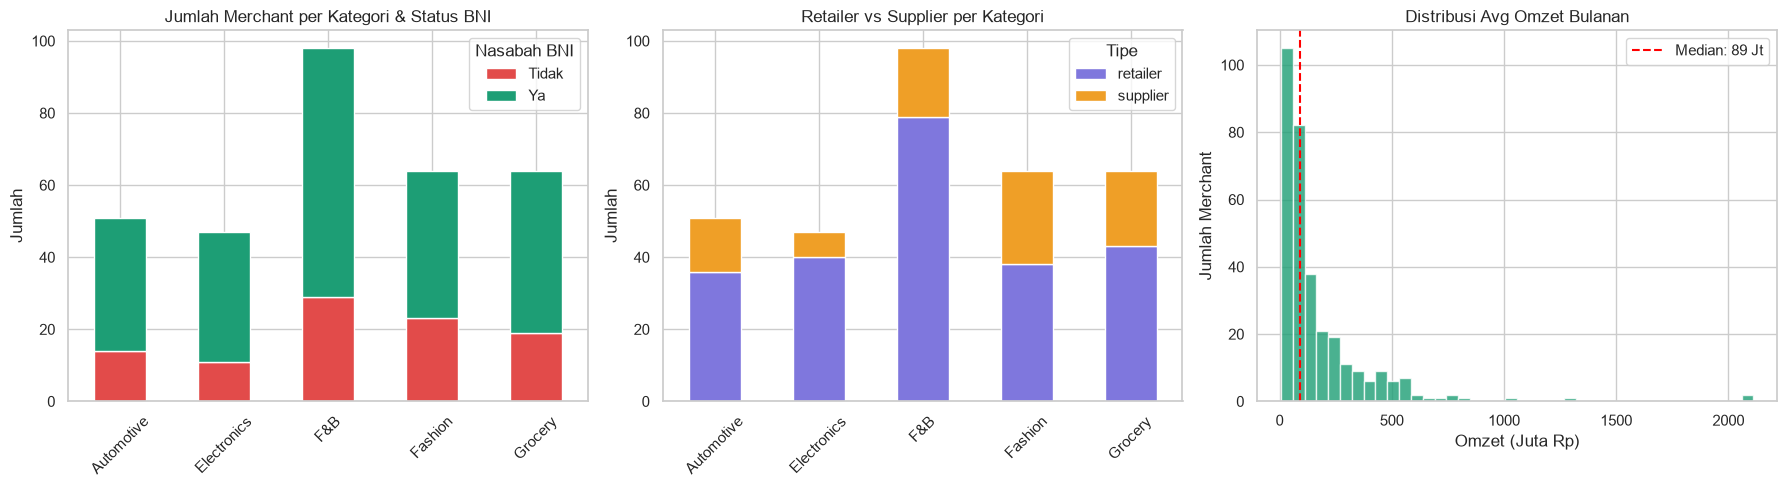

In [35]:
# set the subplots configuration
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Merchant count per kategori, split by BNI status
ct = pd.crosstab(merchants_clean['kategori'], merchants_clean['is_nasabah_bni'])
ct.plot(kind='bar', stacked=True, ax=axes[0], color=['#E24B4A', '#1D9E75'])
axes[0].set_title('Jumlah Merchant per Kategori & Status BNI')
axes[0].set_xlabel('')
axes[0].set_ylabel('Jumlah')
axes[0].legend(title='Nasabah BNI')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Retailer vs Supplier per kategori
ct2 = pd.crosstab(merchants_clean['kategori'], merchants_clean['tipe'])
ct2.plot(kind='bar', stacked=True, ax=axes[1], color=['#7F77DD', '#EF9F27'])
axes[1].set_title('Retailer vs Supplier per Kategori')
axes[1].set_xlabel('')
axes[1].set_ylabel('Jumlah')
axes[1].legend(title='Tipe')
axes[1].tick_params(axis='x', rotation=45)

# Plot 3: Average Omzet Bulanan Distribution
axes[2].hist(merchants_clean['avg_omzet_bulanan'].dropna() / 1e6, bins=40, color='#1D9E75', edgecolor='white', alpha=0.8)
axes[2].set_title('Distribusi Avg Omzet Bulanan')
axes[2].set_xlabel('Omzet (Juta Rp)')
axes[2].set_ylabel('Jumlah Merchant')
axes[2].axvline(merchants_clean['avg_omzet_bulanan'].median() / 1e6, color='red', linestyle='--', label=f"Median: {merchants_clean['avg_omzet_bulanan'].median()/1e6:.0f} Jt")
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/plots/01_merchants_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## **4.2 Transactions Overview**

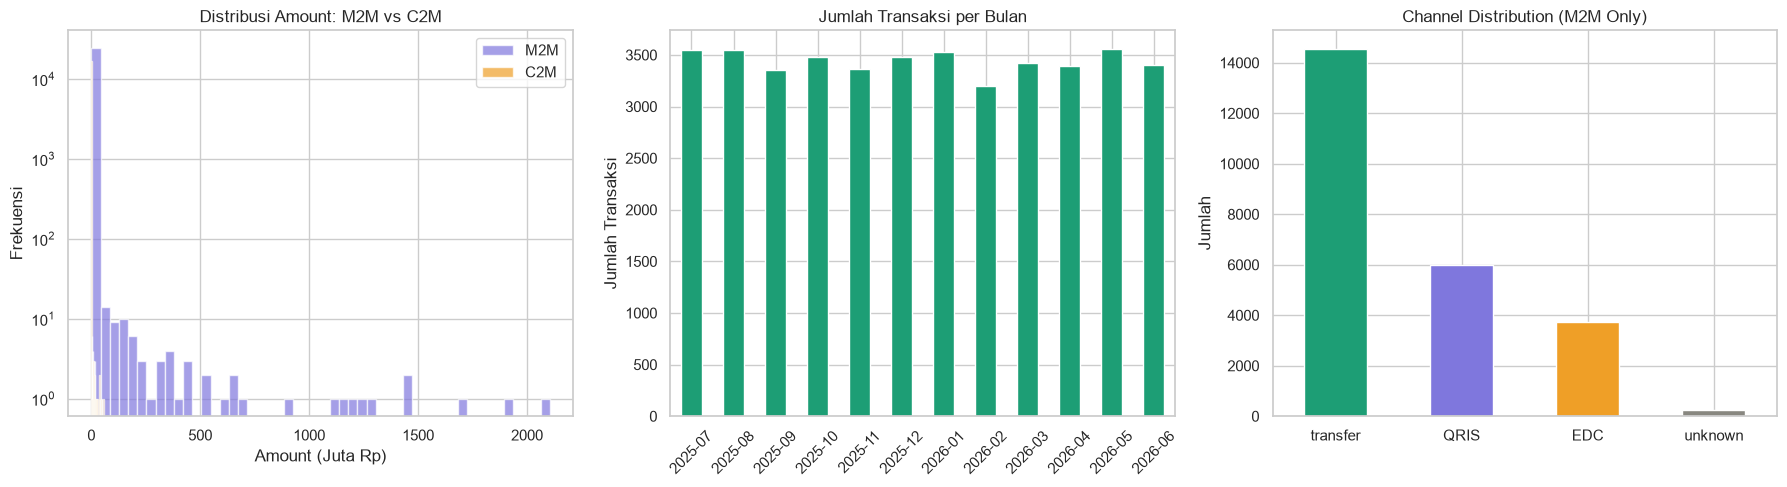

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Distribution amount M2M vs C2M
m2m_amounts = trx_clean[trx_clean['trx_type'] == 'M2M']['amount'] / 1e6
c2m_amounts = trx_clean[trx_clean['trx_type'] == 'C2M']['amount'] / 1e6

axes[0].hist(m2m_amounts, bins=50, alpha=0.7, label='M2M', color='#7F77DD')
axes[0].hist(c2m_amounts, bins=50, alpha=0.7, label='C2M', color='#EF9F27')
axes[0].set_title('Distribusi Amount: M2M vs C2M')
axes[0].set_xlabel('Amount (Juta Rp)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()
axes[0].set_yscale('log')

# Plot 2: Transaction count per month
monthly = trx_clean.groupby('month').size()
monthly.plot(kind='bar', ax=axes[1], color='#1D9E75', edgecolor='white')
axes[1].set_title('Jumlah Transaksi per Bulan')
axes[1].set_xlabel('')
axes[1].set_ylabel('Jumlah Transaksi')
axes[1].tick_params(axis='x', rotation=45)

# Plot 3: Channel distribution for M2M
m2m_channels = trx_clean[trx_clean['trx_type'] == 'M2M']['channel'].value_counts()
m2m_channels.plot(kind='bar', ax=axes[2], color=['#1D9E75', '#7F77DD', '#EF9F27', '#888780'])
axes[2].set_title('Channel Distribution (M2M Only)')
axes[2].set_xlabel('')
axes[2].set_ylabel('Jumlah')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/plots/02_transactions_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## **4.3 Transaction Time Heatmap**

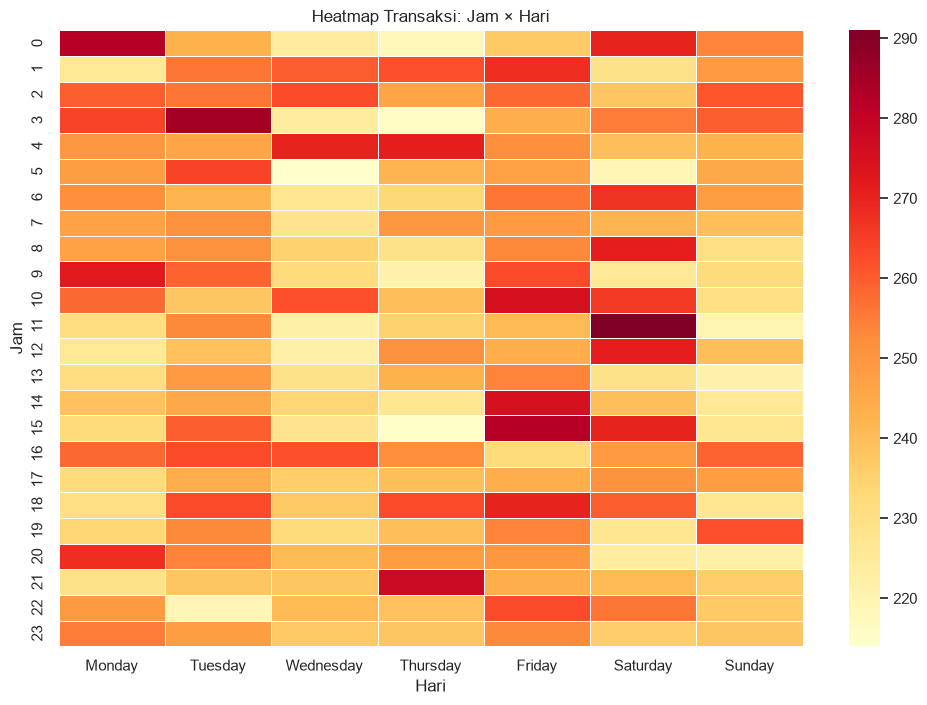

In [37]:
hour_day = trx_clean.pivot_table(index='hour', columns='day_of_week', values='trx_id', aggfunc='count',
                                  fill_value=0)
# Reorder days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
hour_day = hour_day.reindex(columns=[d for d in day_order if d in hour_day.columns])

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(hour_day, cmap='YlOrRd', linewidths=0.5, ax=ax, fmt='d', annot=False)
ax.set_title('Heatmap Transaksi: Jam × Hari')
ax.set_xlabel('Hari')
ax.set_ylabel('Jam')
plt.savefig(f'{PROJECT_ROOT}/plots/03_heatmap_hour_day.png', dpi=150, bbox_inches='tight')
plt.show()

## **4.4 Features Correlation Check**

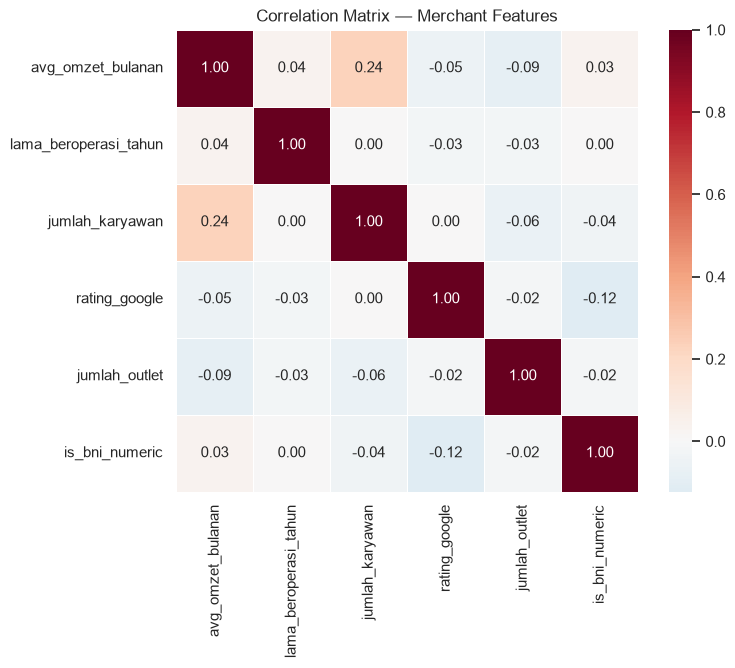

In [38]:
# merge merchants_clean and profile_clean
merchants_enriched = merchants_clean.merge(profile_clean, on='merchant_id', how='left')

# encode is_nasabah_bni to numeric for corrleation analysis
merchants_enriched['is_bni_numeric'] = (merchants_enriched['is_nasabah_bni'] == 'Ya').astype(int)

# Correlation matrix — fitur numerik
numeric_cols = ['avg_omzet_bulanan', 'lama_beroperasi_tahun', 'jumlah_karyawan', 
                'rating_google', 'jumlah_outlet', 'is_bni_numeric']
corr_matrix = merchants_enriched[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            square=True, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix — Merchant Features')
plt.savefig(f'{PROJECT_ROOT}/plots/04_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## **4.5 Data Separation Check**

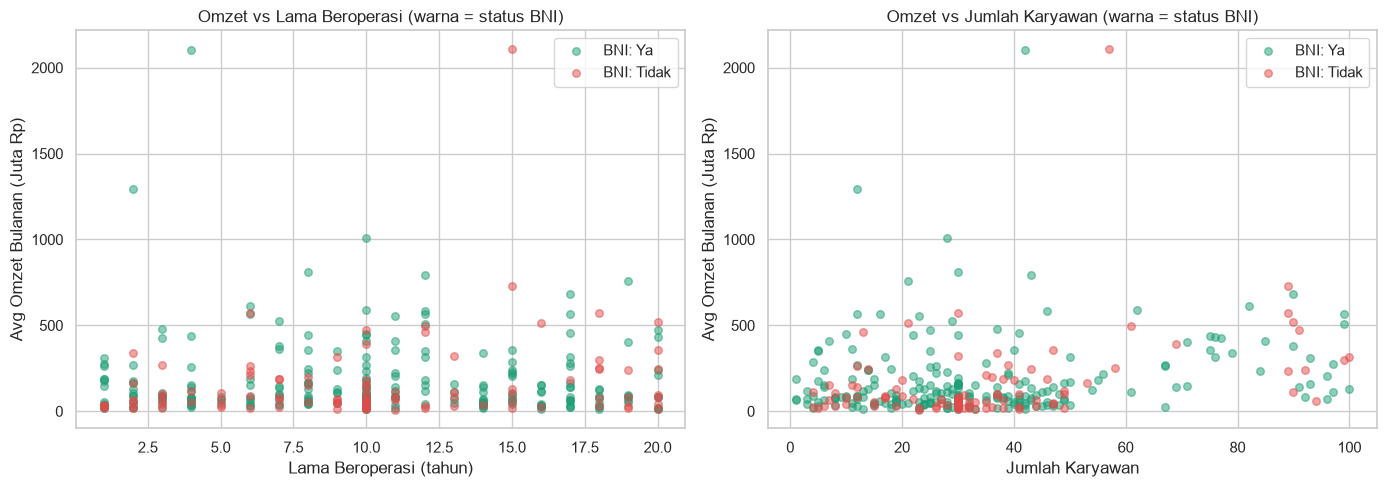

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Ya': '#1D9E75', 'Tidak': '#E24B4A'}

for status, color in colors.items():
    mask = merchants_enriched['is_nasabah_bni'] == status
    axes[0].scatter(
        merchants_enriched.loc[mask, 'lama_beroperasi_tahun'],
        merchants_enriched.loc[mask, 'avg_omzet_bulanan'] / 1e6,
        c=color, alpha=0.5, label=f'BNI: {status}', s=30
    )

axes[0].set_xlabel('Lama Beroperasi (tahun)')
axes[0].set_ylabel('Avg Omzet Bulanan (Juta Rp)')
axes[0].set_title('Omzet vs Lama Beroperasi (warna = status BNI)')
axes[0].legend()

# Scatter: Omzet vs Jumlah Karyawan
for status, color in colors.items():
    mask = merchants_enriched['is_nasabah_bni'] == status
    axes[1].scatter(
        merchants_enriched.loc[mask, 'jumlah_karyawan'],
        merchants_enriched.loc[mask, 'avg_omzet_bulanan'] / 1e6,
        c=color, alpha=0.5, label=f'BNI: {status}', s=30
    )

axes[1].set_xlabel('Jumlah Karyawan')
axes[1].set_ylabel('Avg Omzet Bulanan (Juta Rp)')
axes[1].set_title('Omzet vs Jumlah Karyawan (warna = status BNI)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/plots/05_scatter_nonlinearity.png', dpi=150, bbox_inches='tight')
plt.show()

## **4.6 Supplier Penetration Analysis**

Supplier BNI Penetration per Kategori
is_nasabah_bni  Tidak     Ya
kategori                    
Automotive      20.00  80.00
Electronics     57.14  42.86
F&B             21.05  78.95
Fashion         26.92  73.08
Grocery         28.57  71.43


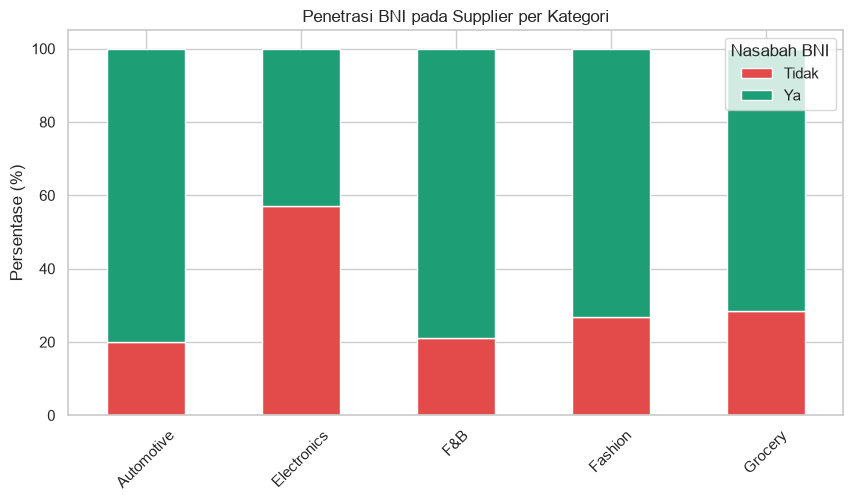

In [40]:
supplier_penetration = (
    merchants_clean[merchants_clean['tipe'] == 'supplier']
    .groupby('kategori')['is_nasabah_bni']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .round(4) * 100
)

print("Supplier BNI Penetration per Kategori")
print(supplier_penetration)

fig, ax = plt.subplots(figsize=(10, 5))
supplier_penetration.plot(kind='bar', stacked=True, ax=ax, color=['#E24B4A', '#1D9E75'])
ax.set_title('Penetrasi BNI pada Supplier per Kategori')
ax.set_xlabel('')
ax.set_ylabel('Persentase (%)')
ax.legend(title='Nasabah BNI')
ax.tick_params(axis='x', rotation=45)
plt.savefig(f'{PROJECT_ROOT}/plots/07_supplier_penetration.png', dpi=150, bbox_inches='tight')
plt.show()

# **5. Building Graph Network Data**

In [41]:
# Filter only M2M transactions
trx_m2m = trx_clean[trx_clean['trx_type'] == 'M2M'].copy()
print(f"Clean transactions total data: {len(trx_clean)}")
print(f"M2M transactions: {len(trx_m2m)}")
print(f"C2M transactions (excluded from graph): {len(trx_clean) - len(trx_m2m)}")

# make sure source_id and target_id appears in merchants_clean
valid_merchant_ids = set(merchants_clean['merchant_id'].tolist())
trx_m2m = trx_m2m[
    trx_m2m['source_id'].isin(valid_merchant_ids) & 
    trx_m2m['target_id'].isin(valid_merchant_ids)
]
print(f"M2M after merchant_id validation process: {len(trx_m2m)}")

Clean transactions total data: 41265
M2M transactions: 24527
C2M transactions (excluded from graph): 16738
M2M after merchant_id validation process: 15985


In [42]:
# build edge_table
edge_table = trx_m2m.groupby(['source_id', 'target_id']).agg(
    total_amount=('amount', 'sum'),
    avg_amount=('amount', 'mean'),
    trx_count=('trx_id', 'count'),
    first_trx=('timestamp_dt', 'min'),
    last_trx=('timestamp_dt', 'max'),
    primary_channel=('channel', lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'unknown'),
    unique_channels=('channel', 'nunique')
).reset_index()

# calculate duration of relationship in months
edge_table['relationship_months'] = (
    (edge_table['last_trx'] - edge_table['first_trx']).dt.days / 30
).round(1)

print(f"Edge Table")
print(f"Jumlah edges (relasi unik): {len(edge_table)}")
print(f"Jumlah nodes terlibat: {len(set(edge_table['source_id']) | set(edge_table['target_id']))}")

Edge Table
Jumlah edges (relasi unik): 616
Jumlah nodes terlibat: 305


In [43]:
# check edge table preview
edge_table.sort_values('total_amount', ascending=False).head(10)

,source_id,target_id,total_amount,avg_amount,trx_count,first_trx,last_trx,primary_channel,unique_channels,relationship_months
319,M0213,M0202,2.495804e+09,6.399497e+07,39,2025-07-14 15:08:06,2026-06-30 13:22:56,transfer,4,11.7
272,M0190,M0149,2.029708e+09,8.457117e+07,24,2025-08-02 10:42:29,2026-05-19 12:10:21,transfer,3,9.7
112,M0106,M0018,1.904401e+09,5.601178e+07,34,2025-07-02 22:46:50,2026-06-30 22:11:04,transfer,4,12.1
217,M0167,M0132,1.561041e+09,6.004004e+07,26,2025-07-16 16:30:21,2026-06-27 21:12:57,transfer,3,11.5
1,M0001,M0114,1.410182e+09,4.406820e+07,32,2025-07-22 07:13:39,2026-06-23 07:44:11,transfer,3,11.2
14,M0011,M0035,1.294150e+09,5.392291e+07,24,2025-08-27 10:14:44,2026-06-22 02:10:46,transfer,3,9.9
477,M0318,M0313,1.268602e+09,5.285843e+07,24,2025-07-08 12:17:55,2026-06-12 03:18:12,transfer,4,11.3
10,M0007,M0035,1.243080e+09,4.603998e+07,27,2025-07-16 13:02:51,2026-06-27 07:58:15,transfer,3,11.5
422,M0269,M0245,8.181354e+08,2.045339e+07,40,2025-07-18 01:47:05,2026-06-19 07:54:34,transfer,4,11.2
76,M0079,M0002,8.147418e+08,3.017562e+07,27,2025-07-06 14:22:14,2026-06-30 13:01:19,transfer,3,11.9


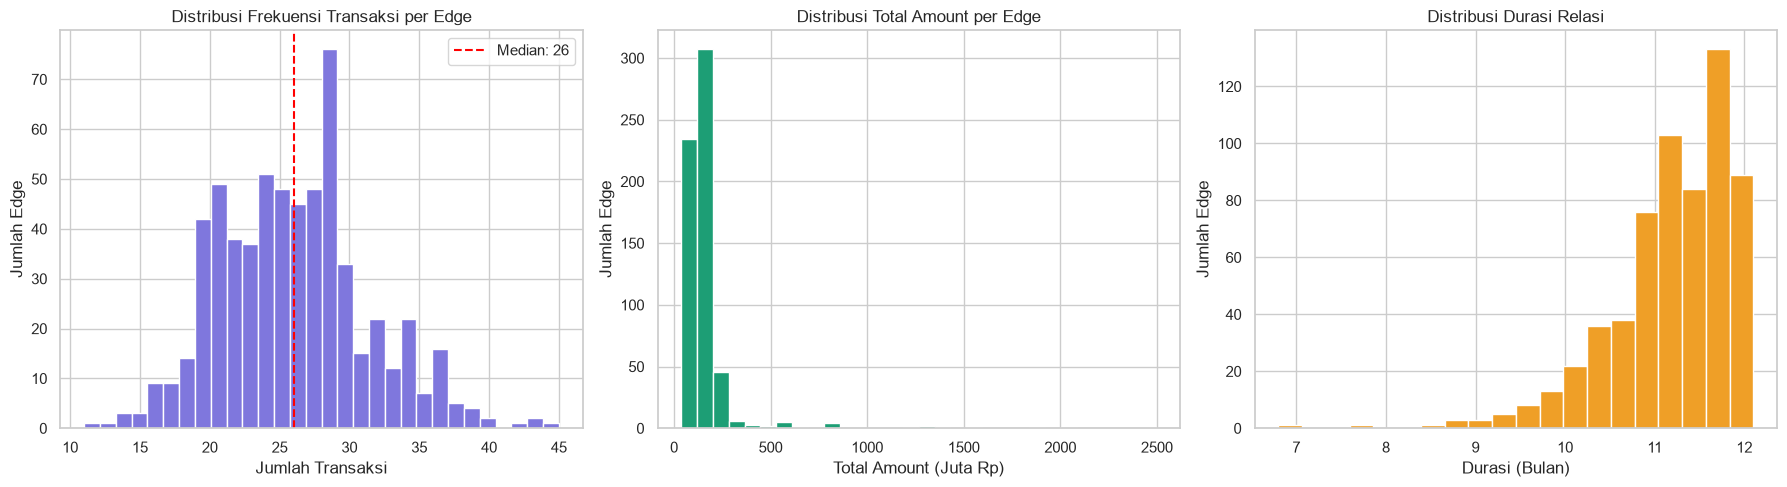

In [45]:
# edge table visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution of trx_count per edge
axes[0].hist(edge_table['trx_count'], bins=30, color='#7F77DD', edgecolor='white')
axes[0].set_title('Distribusi Frekuensi Transaksi per Edge')
axes[0].set_xlabel('Jumlah Transaksi')
axes[0].set_ylabel('Jumlah Edge')
axes[0].axvline(edge_table['trx_count'].median(), color='red', linestyle='--', 
                label=f"Median: {edge_table['trx_count'].median():.0f}")
axes[0].legend()

# Distribution of total_amount per edge
axes[1].hist(edge_table['total_amount'] / 1e6, bins=30, color='#1D9E75', edgecolor='white')
axes[1].set_title('Distribusi Total Amount per Edge')
axes[1].set_xlabel('Total Amount (Juta Rp)')
axes[1].set_ylabel('Jumlah Edge')

# Distribution of relationship_months
axes[2].hist(edge_table['relationship_months'], bins=20, color='#EF9F27', edgecolor='white')
axes[2].set_title('Distribusi Durasi Relasi')
axes[2].set_xlabel('Durasi (Bulan)')
axes[2].set_ylabel('Jumlah Edge')

plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/plots/08_edge_table_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# **6. Save Processed Data**

In [47]:
merchants_clean.to_csv(f'{PROJECT_ROOT}/data/processed/merchants_clean.csv', index=False)
trx_clean.to_csv(f'{PROJECT_ROOT}/data/processed/transactions_clean.csv', index=False)
trx_m2m.to_csv(f'{PROJECT_ROOT}/data/processed/transactions_m2m.csv', index=False)
edge_table.to_csv(f'{PROJECT_ROOT}/data/processed/edge_table.csv', index=False)
profile_clean.to_csv(f'{PROJECT_ROOT}/data/processed/profiles_clean.csv', index=False)
merchants_enriched.to_csv(f'{PROJECT_ROOT}/data/processed/merchants_enriched.csv', index=False)

print("Saving processed data. . .")
print(f"merchants_clean.csv:      {len(merchants_clean)} rows")
print(f"transactions_clean.csv:   {len(trx_clean)} rows")
print(f"transactions_m2m.csv:     {len(trx_m2m)} rows")
print(f"edge_table.csv:           {len(edge_table)} rows")
print(f"profiles_clean.csv:       {len(profile_clean)} rows")
print(f"merchants_enriched.csv:   {len(merchants_enriched)} rows")

Saving processed data. . .
merchants_clean.csv:      324 rows
transactions_clean.csv:   41265 rows
transactions_m2m.csv:     15985 rows
edge_table.csv:           616 rows
profiles_clean.csv:       408 rows
merchants_enriched.csv:   324 rows
